In [1]:
import pandas as pd
import numpy as np


np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "Age": np.random.randint(20, 70, n),
    "Education": np.random.randint(10, 20, n),
    "Income": np.random.normal(5000, 1500, n)
})

logit_score = -1 + 0.0008 * data["Income"]
p_missing = 1 / (1 + np.exp(-logit_score))

random_values = np.random.rand(n)
mask = random_values < p_missing

data_missing = data.copy()
data_missing.loc[mask, "Income"] = np.nan

data.to_csv("dataset_goc.csv", index=False, encoding="utf-8")
data_missing.to_csv("dataset_missing.csv", index=False, encoding="utf-8")

print("Đã lưu thành công dữ liệu!")


Đã lưu thành công dữ liệu!


In [ ]:
print((data_missing.isnull().sum() / data.size )* 100)

Age           0.000000
Education     0.000000
Income       30.566667
dtype: float64


<Axes: >

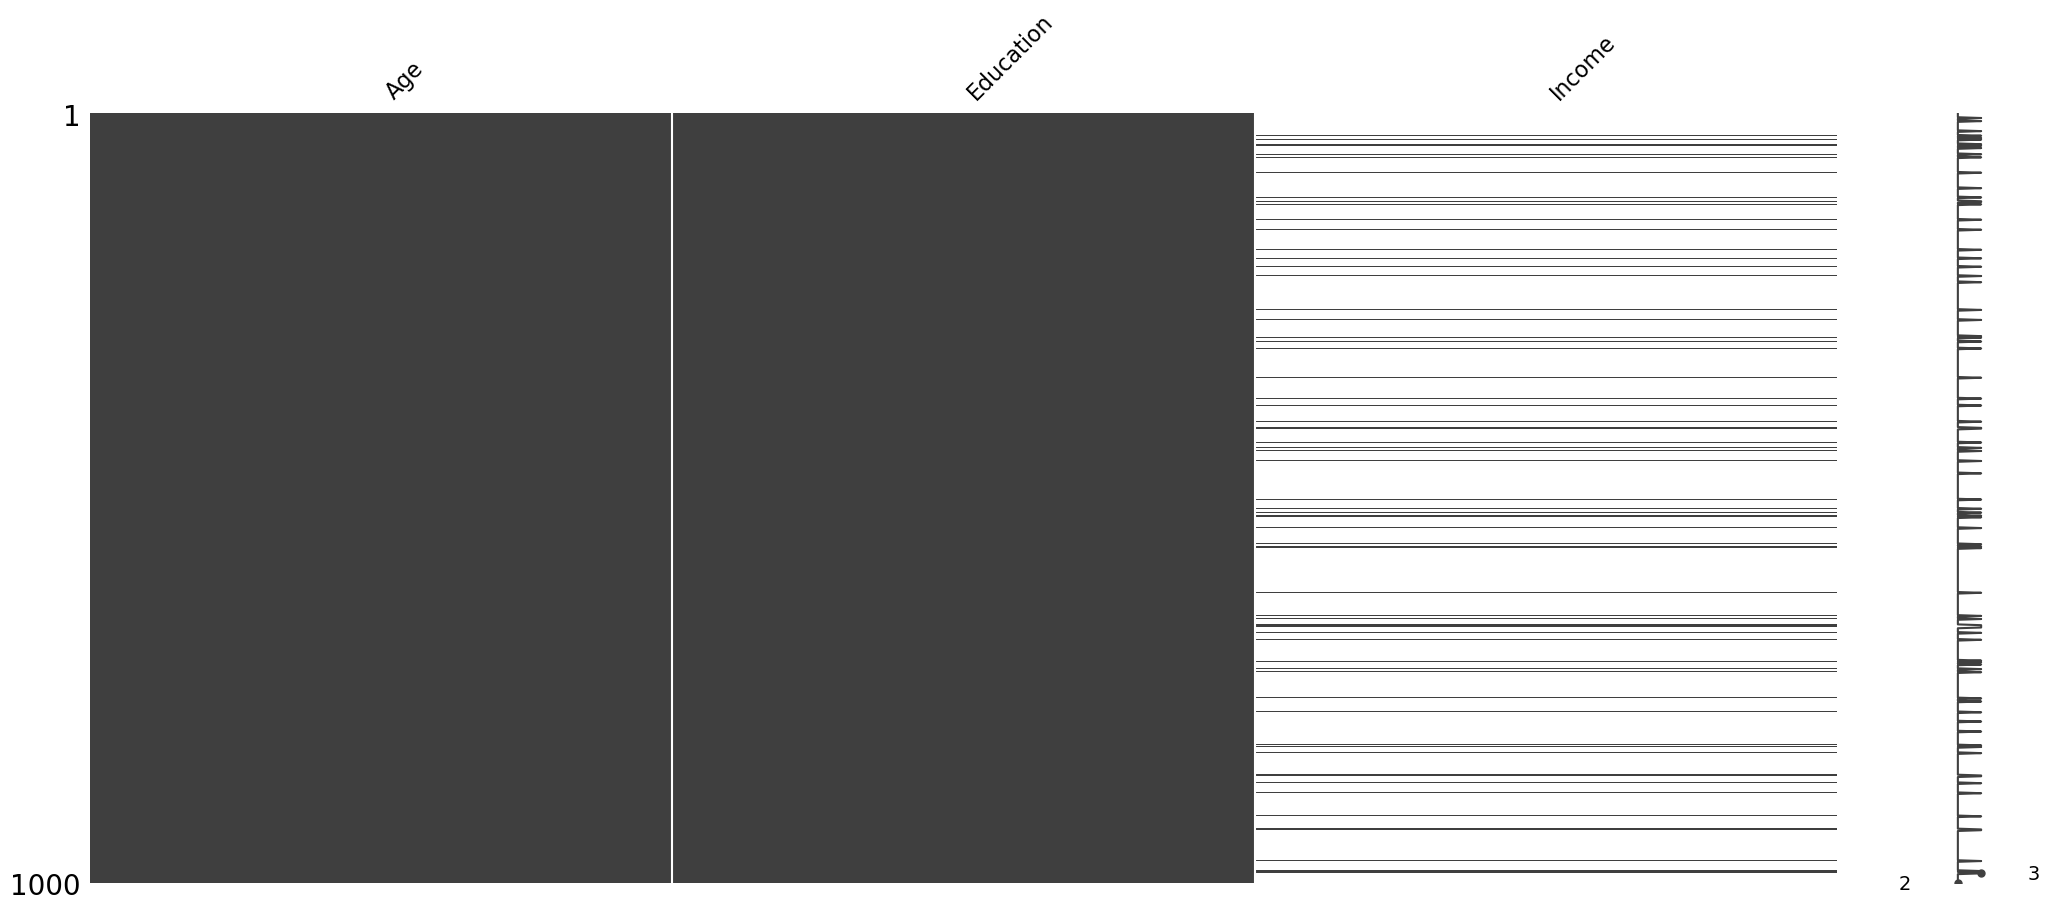

In [ ]:
import missingno as msno
msno.matrix(data_missing)

In [ ]:
msno.dendrogram(data_missing)

In [ ]:
from sklearn.impute import SimpleImputer
simpleimputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')

from sklearn.impute import KNNImputer 
knnimputer = KNNImputer(missing_values = np.nan, n_neighbors = 5, weights = 'uniform')


In [ ]:
data_simple = simpleimputer.fit_transform(X = data_missing)
data_knn = knnimputer.fit_transform(X=data_missing)

In [ ]:
from sklearn.metrics import mean_absolute_error
mae_simple = mean_absolute_error(data_simple, data)
mae_knn = mean_absolute_error(data_knn, data)

In [ ]:
print(mae_simple)
print(mae_knn)

571.1916158963935
578.2201567651188
